In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from DoE_module import x2fx, standardize, dispersion, corrcov, ttest_ind, t as sp_t

from ipywidgets import interact, FloatSlider

# Series 3: Sensitivity of the Young modulus

## Statement
The data is relative to a set of experiments on steal samples with different concentration in carbon and sulfure, tested at different temperatures in order to determine the elastic behavior of the material.The content of the table corresponds to the experimental conditions as well as the Young modulus following the Hooke phenomenological relation:

$$\varepsilon = \frac{\sigma}{E}$$

with $\varepsilon$ the strain, $\sigma$ the longitudinat stress and $E$ the Young modulus.

## Data loading
- Load the experimental data from the provided data file into a table for analysis.

## Pre-experiment Model Analysis
(before experiment execution)
- Critically analyze the design of the experiment for both a linear model and a model including interactions between carbon (C) and sulfur (S).
- For each model, determine and document:
    - The model equation,
    - The dispersion and correlation matrices,
    - The Variance Inflation Factor (VIF) for multicollinearity,
    - The overall variance of the model.
- Summarize these elements and prepare a set of recommendations for the experimenters, assuming the experiments have not yet been conducted.

## Post-experiment Analysis
(after experiment execution)
- Infer the main effects and the interaction between the concentration of carbon (C) and sulfur (S) on the Young’s modulus of the material, using normalized metrics.
- Transform the estimated coefficients back into their original metrics for practical interpretation.

## Confidence Interval Calculation
- Compute the 95% confidence intervals for all the model coefficients to assess the precision of the estimates.

## Conclusion Preparation
- Draft a preliminary conclusion for a report that reflects the results of the experiment, focusing on the quality of the measurements and their implications.

## Future Experiment Recommendations:
- Prepare recommendations for a second experimental campaign that includes an evaluation of potential interactions with temperature. Suggest any design improvements needed to study these new factors.

# 1 - Importing data from excel

In [ ]:
df = pd.read_excel("S2/DataModuleYoung.xlsx", skiprows=1, index_col="Run")
display(df)

,C,S,T,E_1,E_2,E_3
Run,,,,,,
1,0.04,0.4,-20,207.15,206.74,208.36
2,0.04,0.4,0,206.45,204.71,206.83
3,0.04,0.4,20,206.03,203.22,206.34
4,0.04,0.8,0,194.51,192.89,195.03
5,0.05,0.6,0,209.13,209.09,210.38
6,0.06,0.4,0,222.86,221.29,222.08
7,0.06,0.8,-20,214.56,212.06,211.84
8,0.06,0.8,0,209.52,209.86,211.35
9,0.06,0.8,20,211.89,210.20,209.24


# 2 - Analyzing of the design

The steps are :

a) Extraction of the matrix of essays from the data

b) Normalization of the matrix of essays

In [4]:
M_essays = df[["C", "S", "T"]]
display(M_essays)

,C,S,T
Run,,,
1,0.04,0.4,-20
2,0.04,0.4,0
3,0.04,0.4,20
4,0.04,0.8,0
5,0.05,0.6,0
6,0.06,0.4,0
7,0.06,0.8,-20
8,0.06,0.8,0
9,0.06,0.8,20


In [5]:
E = standardize(M_essays)
display(np.round(E, 3))

,C,S,T
Run,,,
1,-1.0,-1.0,-1.0
2,-1.0,-1.0,0.0
3,-1.0,-1.0,1.0
4,-1.0,1.0,0.0
5,0.0,-0.0,0.0
6,1.0,-1.0,0.0
7,1.0,1.0,-1.0
8,1.0,1.0,0.0
9,1.0,1.0,1.0


c) Building of the model matrix for the linear model with interaction

$$y = a_0 + a_C x_C + a_S x_S + s_T x_T + a_{CS} x_C x_S$$

We use the coefficient spec matrix with one column per factor and one row per coefficient.
Then for our situation the matrix is

$$\text{spec}=\begin{pmatrix}
    0 & 0 & 0\\
    1 & 0 & 0\\
    0 & 1 & 0\\
    0 & 0 & 1\\
    1 & 1 & 0\\
\end{pmatrix}$$

for the coefficients $a_C$, $a_S$, $a_T$ and $a_{CS}$.

In [6]:
spec = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [1, 1, 0]
])

In [7]:
M = x2fx("C+S+T+C:S", E)
M = x2fx(spec, E)
display(pd.DataFrame(np.round(M),
                     columns=["Intercept", "x_C", "x_S", "x_T", "x_{CS}"],
                     index=["E_%i" % i for i in range(1, E.shape[0]+1)]))

,Intercept,x_C,x_S,x_T,x_{CS}
E_1,1.0,-1.0,-1.0,-1.0,1.0
E_2,1.0,-1.0,-1.0,0.0,1.0
E_3,1.0,-1.0,-1.0,1.0,1.0
E_4,1.0,-1.0,1.0,0.0,-1.0
E_5,1.0,0.0,-0.0,0.0,-0.0
E_6,1.0,1.0,-1.0,0.0,-1.0
E_7,1.0,1.0,1.0,-1.0,1.0
E_8,1.0,1.0,1.0,0.0,1.0
E_9,1.0,1.0,1.0,1.0,1.0


d) Computation of the dispersion matrix

,a_0,a_C,a_S,a_T,a_{CS}
a_0,0.14,-0.00,0.00,0.00,-0.07
a_C,-0.00,0.17,-0.08,0.00,0.00
a_S,0.00,-0.08,0.17,0.00,-0.00
a_T,0.00,0.00,0.00,0.25,0.00
a_{CS},-0.07,0.00,-0.00,0.00,0.16


np.trace(D) = 8.87e-01
np.linalg.det(D) = 9.30e-05


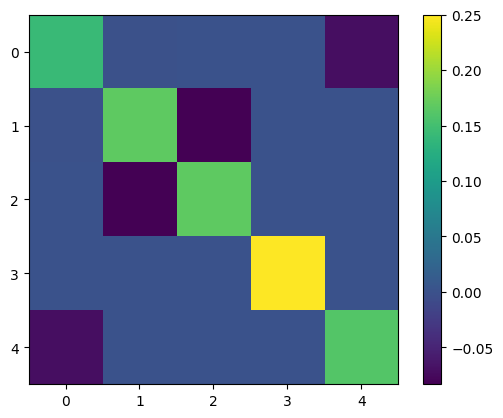

In [8]:
D = dispersion(M)

list_coefs = ["a_0", "a_C", "a_S", "a_T", "a_{CS}"]
display(pd.DataFrame(np.round(D, 2),
                     columns=list_coefs,
                     index=list_coefs))

print(f"{np.trace(D) = :.2e}")
print(f"{np.linalg.det(D) = :.2e}")
plt.imshow(D)
plt.colorbar()
plt.show()

e) Computation of the correlation matrix

In [9]:
C = corrcov(D)
display(pd.DataFrame(np.round(C, 2),
                     columns=list_coefs,
                     index=list_coefs))

,a_0,a_C,a_S,a_T,a_{CS}
a_0,1.00,-0.0,0.0,0.0,-0.47
a_C,-0.00,1.0,-0.5,0.0,0.00
a_S,0.00,-0.5,1.0,0.0,-0.00
a_T,0.00,0.0,0.0,1.0,0.00
a_{CS},-0.47,0.0,-0.0,0.0,1.00


We can observe a correlation of -0.5 between the main effects of carbon and and sulfur, as well as between the constant $a_0$ and the interaction effect $a_{SC}$.

A correlation coefficient of -0.5 between the estimates of two main effects in a linear model with interactions suggests a moderate negative correlation. Here are some possible comments and interpretations you could make on this value:
1. **Moderate Negative Correlation:** The value of -0.5 indicates that as one main effect increases, the other tends to decrease, but the relationship is not perfectly linear. It’s a moderate inverse relationship, suggesting that there is some dependency between these two main effects.
2. **Multicollinearity Concern:** While a correlation of -0.5 does not indicate severe multicollinearity (which would generally be observed with correlations closer to -1 or 1), it does point to some level of association between these variables. This could influence the stability of the coefficient estimates in the model. You might want to further explore the Variance Inflation Factor (VIF) for a more robust assessment of multicollinearity.
3. **Impact on Interpretation:** When interpreting the results, it’s important to note that the negative correlation between the two main effects may make it more difficult to separate their individual impacts on the response variable. This interdependence could lead to some confounding in the interpretation of their coefficients.

In summary, while a correlation of -0.5 is not necessarily alarming, it does warrant attention and further investigation to ensure that the model coefficients are reliable and interpretable.

f) Computation of the variance inflation factors (VIF)

In [10]:
VIF = np.diag(np.linalg.inv(C))
display(pd.DataFrame(np.round(VIF, 2),
                     columns=["VIF"],
                     index=list_coefs))

,VIF
a_0,1.29
a_C,1.33
a_S,1.33
a_T,1.00
a_{CS},1.29


Theses VIF values between 1 and 1.33 indicate a well-behaved model with respect to multicollinearity. There is minimal correlation between the regressors, and this should allow for clear interpretation of the main effects and interactions. No corrective action is needed for multicollinearity based on these values.

g) **Plot** of the position of the measurement points

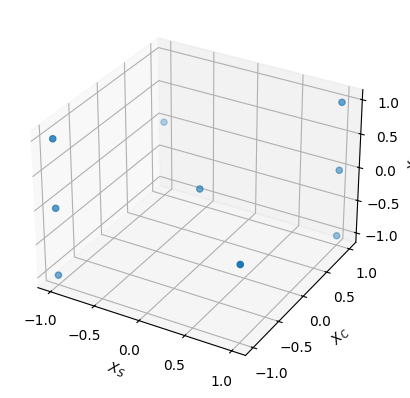

In [11]:
ax = plt.subplot(projection="3d")
ax.scatter(E.S, E.C, E["T"])  # E.T is the transposed of E
ax.set_xlabel("$X_S$")
ax.set_ylabel("$X_C$")
ax.set_zlabel("$X_T$")
plt.show()

Even if the distribution of the points of measurements is non uniform, the design is spread all over the experimental space. This ensure a good estimation of the linear coefficients (but not for the interaction coefficients between the temperature and the two other factors).

h) Computation of the **variance function**

In [12]:
%matplotlib inline
xc = np.linspace(-1, 1, num=100)
xs = np.linspace(-1, 1, num=100)
xt = np.linspace(-1, 1, num=100)

def update_xt(xt):
    Xc, Xs = np.meshgrid(xc, xs, indexing="ij")
    fx = np.array([
        np.ones(Xc.shape),
        Xc, 
        Xs,
        np.full(Xc.shape, xt),
        Xc*Xs
    ])
    v = np.einsum("i...,ij,j...->...", fx, D, fx)
    fig, ax = plt.subplots(subplot_kw=dict(projection="3d"))
    ax.set_title("Variance function - linear model with interaction")
    ax.plot_surface(Xc, Xs, v, cmap="viridis")
    ax.scatter(E.C, E.S, zorder=0)
    ax.set_zlim(0,1)
    plt.show()

i = interact(
    update_xt,
    xt=FloatSlider(min=-1, max=1, value=0),
)

interactive(children=(FloatSlider(value=0.0, description='xt', max=1.0, min=-1.0), Output()), _dom_classes=('w…

In [13]:
def update_xt(xt):
    Xc, Xs = np.meshgrid(xc, xs, indexing="ij")
    fx = np.array([
        np.ones(Xc.shape),
        Xc, 
        Xs,
        np.full(Xc.shape, xt),
        Xc*xs
    ])
    v = np.einsum("i...,ij,j...->...", fx, D, fx)
    plt.title("Variance function - linear model with interaction")
    extent = Xc.min(), Xc.max(), Xs.min(), Xs.max()
    plt.imshow(v, cmap="viridis", extent=extent, origin="lower")
    plt.scatter(E.C, E.S, c="r")
    plt.colorbar()
    plt.show()

i = interact(
    update_xt,
    xt=FloatSlider(min=-1, max=1, value=0),
)

interactive(children=(FloatSlider(value=0.0, description='xt', max=1.0, min=-1.0), Output()), _dom_classes=('w…

In [14]:
%matplotlib inline

def update_xs(xs):
    Xc, Xt = np.meshgrid(xc, xt, indexing="ij")
    fx = np.array([
        np.ones(Xc.shape),
        Xc, 
        np.full(Xc.shape, xs),
        Xt,
        Xc*xs
    ])
    v = np.einsum("i...,ij,j...->...", fx, D, fx)
    fig, ax = plt.subplots(subplot_kw=dict(projection="3d"))
    ax.plot_surface(Xc, Xt, v, cmap="viridis")
    ax.set_zlim(0,1)
    ax.scatter(E['C'], E['T'], zorder=0)
    plt.show()


i = interact(
    update_xs,
    xs=FloatSlider(min=-1, max=1, value=0),
)

interactive(children=(FloatSlider(value=0.0, description='xs', max=1.0, min=-1.0), Output()), _dom_classes=('w…

# Evaluation of the experimental design

1. Overall Design Evaluation:

The current design is non-optimal, but it remains practicable for the purposes of this experiment. While the design is not ideal, it provides useful data and allows for reasonable conclusions to be drawn.

2. Dispersion Matrix Analysis:

The diagonal elements of the dispersion matrix fall between 14% and 25%, which means that 14% to 25% of the sample variance is being attributed to the estimation of the model coefficients. Ideally, in this case, we would aim for a diagonal element value of 1/9 (approximately 11%). This comparison indicates that the design is somewhat inefficient but still within acceptable limits.

3. Correlation Between Regressors:

The correlation matrix shows that there is moderate collinearity between between the estimators of  and and between those of and . This implies that the estimates of these coefficients are not fully independent, which could slightly affect the precision of the estimated coefficients. However, the collinearity does not reach a critical level that would invalidate the results or require significant corrective measures.

4. Impact on Confidence Intervals:

Due to this moderate collinearity, we expect wider confidence intervals for the affected coefficients. Specifically, the confidence intervals may be inflated by approximately 15% (as the square root of the VIF, 1.33, is 1.15). This increase means that there will be slightly less precision in estimating the effects, but this is still manageable within the experimental constraints.

5. Variance Function and Sensitivity:

The analysis of the variance function suggests that the quality of the model deteriorates when the concentrations of carbon and sulfur move in opposite directions (i.e., one high and one low). This region corresponds to areas where the design lacks coverage, with only a single measurement point in these corners, compared to three measurements in the other corner regions of the design space. This highlights a lack of balance in the design, which affects the model's ability to accurately predict responses in these regions.

6. Design Improvement Proposal:

To address the issue of variance and improve the robustness of the model, it would be beneficial to replicate the experiments at the high-low and low-high points, eventually changing the temperature.

**Replication in these regions would:**

- Increase the number of measurements in the areas where the model is currently weakest.
- Help reduce variance and improve the stability of the model in those regions.
- Likely decrease the confidence intervals by improving the overall balance of the design, leading to more precise estimates of the interaction effects between carbon and sulfur.

This adjustment could bring the design closer to the optimal scenario and mitigate the model's sensitivity to specific factor combinations.

**Replication of the high-low and low-high points**

Let's make a proposal to improve the variance function.Additional points placed on the plane corresponding to the median temperature ($x_T=0$), with the carbon and the sulfure at the oposite extreme high-low and low-high:

$$E_2 = \begin{pmatrix}
    -1 & 1 & 0\\
    1 & -1 & 0\\
    -1 & 1 & 0\\
    1 & -1 & 0\\
\end{pmatrix}$$

In [15]:
E2 = pd.concat((E, pd.DataFrame([
    [-1,  1,  0],
    [ 1, -1,  0],
    [-1,  1,  0],
    [ 1, -1,  0],
], columns=["C", "S", "T"])))

1) A new matrix of the model is built, concatenated to the previous one and a new dispersion matrix is computed:

In [16]:
M2 = x2fx("C+S+T+C:S", E2)
display(np.round(M2, 3))
D2 = dispersion(M2)
display(pd.DataFrame(np.round(D2, 3), columns=list_coefs, index=list_coefs))

,Intercept,C,S,T,C:S
1,1.0,-1.0,-1.0,-1.0,1.0
2,1.0,-1.0,-1.0,0.0,1.0
3,1.0,-1.0,-1.0,1.0,1.0
4,1.0,-1.0,1.0,0.0,-1.0
5,1.0,0.0,-0.0,0.0,-0.0
6,1.0,1.0,-1.0,0.0,-1.0
7,1.0,1.0,1.0,-1.0,1.0
8,1.0,1.0,1.0,0.0,1.0
9,1.0,1.0,1.0,1.0,1.0
0,1.0,-1.0,1.0,0.0,-1.0


,a_0,a_C,a_S,a_T,a_{CS}
a_0,0.077,-0.000,0.000,0.00,0.000
a_C,-0.000,0.083,0.000,0.00,0.000
a_S,0.000,0.000,0.083,0.00,0.000
a_T,0.000,0.000,0.000,0.25,0.000
a_{CS},0.000,0.000,0.000,0.00,0.083


2) After that a new variance function  is built as a function.

In [17]:
def variance(fx, D):
    # fx contains matrices instead of simple values
    return np.einsum("i...,ij,j...->...", fx, D, fx)

3) A slider is defined for selecting the value of  when representing the variance function as a 2D surface.

In [18]:
def update_xt2(xt):
    Xc, Xs = np.meshgrid(xc, xs)
    fx = np.array([
        np.ones(Xc.shape),
        Xc, 
        Xs,
        np.full(Xc.shape, xt),
        Xc*Xs
    ])
    v = variance(fx, D)
    v2 = variance(fx, D2)
    vmin = min(v.min(), v2.min())
    vmax = max(v.max(), v2.max())
    fig, ax = plt.subplots(subplot_kw=dict(projection="3d"))
    ax.plot_surface(Xc, Xs, v, cmap="viridis", antialiased=False, vmin=vmin, vmax=vmax)
    ax.scatter(E.C, E.S)
    ax.plot_surface(Xc, Xs, v2, cmap="viridis", antialiased=False, vmin=vmin, vmax=vmax)
    ax.set_xlabel("$x_S$")
    ax.set_ylabel("$x_C$")
    ax.set_zlabel(r"$\mathrm{var}(E)/\sigma^2$")
    plt.show()


i = interact(
    update_xt2,
    xt=FloatSlider(min=-1, max=1, value=1),
)

interactive(children=(FloatSlider(value=1.0, description='xt', max=1.0, min=-1.0), Output()), _dom_classes=('w…

In [19]:
def update_xt2(xt):
    Xc, Xs = np.meshgrid(xc, xs)
    fx = np.array([
        np.ones(Xc.shape),
        Xc, 
        Xs,
        np.full(Xc.shape, xt),
        Xc*Xs
    ])
    v = variance(fx, D)
    v2 = variance(fx, D2)
    fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
    ext = Xc.min(), Xc.max(), Xs.min(), Xs.max()
    ax[0].imshow(v, cmap="viridis", extent=ext, origin="lower")
    ax[1].imshow(v2, cmap="viridis", extent=ext, origin="lower")
    ax[0].set_xlabel("$x_C$")
    ax[0].set_ylabel("$x_S$")
    plt.show()


i = interact(
    update_xt2,
    xt=FloatSlider(min=-1, max=1, value=1),
)

interactive(children=(FloatSlider(value=1.0, description='xt', max=1.0, min=-1.0), Output()), _dom_classes=('w…

We observe that replicating the **high-low** and **low-high** points would lead to a **significant reduction in the variance function** at these positions, thereby enhancing the model’s accuracy in these regions. Therefore, this is a strong recommendation to pass on to the experimenters. While this adjustment will not directly improve the model’s resolution with respect to **temperature**, it will notably enhance the precision of the estimates for the **concentrations of Carbon and Sulfur**.

# 3 - Analysis of the experiments

There are **three replicates** in the experiment. It is good practice to check whether there are **significant differences** between these sets. Several methods can be used to assess this:
- **Visual inspection:** Plot the data in parallel to identify any obvious trends or discrepancies.
- **Boxplots:** Use boxplots to visually compare the distributions and detect any outliers or shifts in central tendency.
- **Statistical comparison:** Compare the **means** and **standard deviations** of the replicates to quantitatively assess differences and variability.

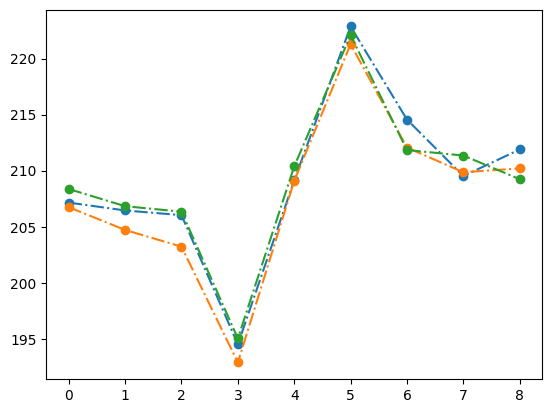

In [20]:
plt.plot(np.column_stack((df.E_1, df.E_2, df.E_3)), "-.o")
plt.show()

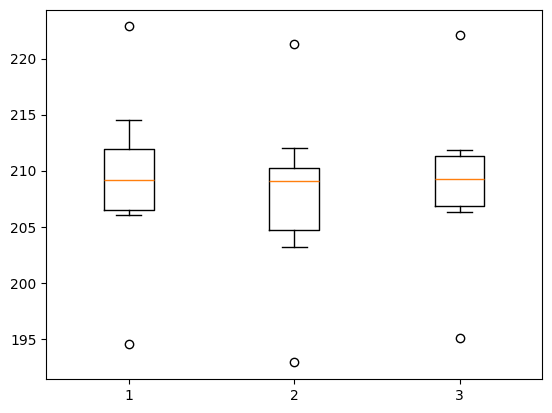

In [21]:
plt.boxplot(df[["E_1", "E_2", "E_3"]])
plt.show()

The plot indicates a **similar behavior** across the sets. However, the **boxplot** reveals some **minor differences** between the three sets. Notably, the **second set** has a **lower average** than the others, while the **third set** exhibits a **smaller standard deviation**. In this situation, it would be useful to apply a **T-test** to determine whether these differences are statistically significant:

In [22]:
means = df[["E_1", "E_2", "E_3"]].mean()
display(means)
std = df[["E_1", "E_2", "E_3"]].std()
display(std)

E_1    209.122222
E_2    207.784444
E_3    209.050000
dtype: float64

E_1    7.584723
E_2    7.630116
E_3    7.017558
dtype: float64

In [23]:
ttest = ttest_ind(df.E_1, df.E_2)
tstat, pval = ttest
l, h = ttest.confidence_interval(0.95)
print(l, h)
print(tstat, pval)

-6.264601097808003 8.940156653363552
0.3730361570638007 0.7140174151485603


Finally, the T-test does not provide sufficient evidence to reject the null hypothesis, indicating that the three sets likely come from populations with the same means and standard deviations. Therefore, we can proceed with confidence, knowing that the three sets can be analyzed together.

## Calculation of the coefficients of the model with interactions

The least squares algorithm will be used to estimate the model parameters. To do this, the **model matrix** must be constructed to include all three replicates. This is achieved by concatenating the matrix for the basic design **three times vertically**, ensuring that the replicates are incorporated into the analysis.

In [24]:
M3 = np.vstack((M, M, M))
R = np.hstack((df.E_1, df.E_2, df.E_3))
Half_effects = np.linalg.solve(M3.T @ M3, M3.T @ R)

It is interesting to compute the relative half-effects. They ease the analysis letting to seen rapidly the importance of the effects in relation with the constant.

In [25]:
Rel_effects = Half_effects / Half_effects[0]

**Calculation of the confidence intervals**

In [26]:
beta = 0.95
alpha = 1-beta
dof = M3.shape[0] - M3.shape[1]
t_student = sp_t.ppf(beta + alpha/2, dof)

residue = R - M3 @ Half_effects
var_exp = residue.T @ residue /(dof)
D3 = np.linalg.inv(M3.T @ M3)
CI = t_student * np.sqrt(np.diag(D3) * var_exp)

display(pd.DataFrame(
    np.round(np.vstack((Half_effects.T, CI.T, Rel_effects.T)), 2),
    index=["Half-effects", f"{beta:.0%} CI", "Relative"],
    columns=list_coefs
))

,a_0,a_C,a_S,a_T,a_{CS}
Half-effects,208.56,8.22,-5.74,-1.15,0.21
95% CI,0.55,0.59,0.59,0.72,0.58
Relative,1.00,0.04,-0.03,-0.01,0.00
